In [1]:
import torch
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
GPU: Tesla T4


In [2]:
# ETAPA 5 - Fine-tuning parcial del modelo generativo
# CELDA 1: reconstruccion completa de datos + tokenizacion + congelamiento parcial

!pip install -q transformers sentencepiece accelerate evaluate rouge_score datasets

import re
import pandas as pd
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# --------------------------------------------------
# 1. Verificacion de GPU
# --------------------------------------------------
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
else:
    print("ATENCION: no hay GPU activa")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# 2. Carga del dataset original
# --------------------------------------------------
df = pd.read_csv(
    "/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

print("\nShape original:", df.shape)
print("Columnas originales:", df.columns.tolist())

# --------------------------------------------------
# 3. Seleccion y limpieza
# --------------------------------------------------
df = df[["Id", "ProductId", "Score", "Summary", "Text"]].copy()
df = df.dropna(subset=["Score", "Text"]).copy()

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["Text_clean"] = df["Text"].apply(limpiar_texto)
df["Summary_clean"] = df["Summary"].fillna("").apply(limpiar_texto)

df = df[df["Text_clean"].str.len() > 0].copy()

def convertir_sentimiento(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(convertir_sentimiento)

print("\nShape limpio:", df.shape)
print("\nDistribucion de sentimiento:")
print(df["sentiment"].value_counts())

# --------------------------------------------------
# 4. Reconstruccion de splits generativos (70 / 15 / 15)
# --------------------------------------------------
X_text = df["Text_clean"]
X_summary = df["Summary_clean"]
y = df["sentiment"]

X_text_temp, X_text_test, X_summary_temp, X_summary_test, y_temp, y_test = train_test_split(
    X_text,
    X_summary,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_text_train, X_text_val, X_summary_train, X_summary_val, y_train, y_val = train_test_split(
    X_text_temp,
    X_summary_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

train_df_gen = pd.DataFrame({
    "Text_clean": X_text_train,
    "Summary_clean": X_summary_train,
    "sentiment": y_train
}).reset_index(drop=True)

val_df_gen = pd.DataFrame({
    "Text_clean": X_text_val,
    "Summary_clean": X_summary_val,
    "sentiment": y_val
}).reset_index(drop=True)

test_df_gen = pd.DataFrame({
    "Text_clean": X_text_test,
    "Summary_clean": X_summary_test,
    "sentiment": y_test
}).reset_index(drop=True)

print("\nShapes reconstruidos:")
print("Train:", train_df_gen.shape)
print("Val  :", val_df_gen.shape)
print("Test :", test_df_gen.shape)

# --------------------------------------------------
# 5. Eliminar summaries vacios
# --------------------------------------------------
train_df_gen = train_df_gen[train_df_gen["Summary_clean"].fillna("").str.len() > 0].copy().reset_index(drop=True)
val_df_gen   = val_df_gen[val_df_gen["Summary_clean"].fillna("").str.len() > 0].copy().reset_index(drop=True)
test_df_gen  = test_df_gen[test_df_gen["Summary_clean"].fillna("").str.len() > 0].copy().reset_index(drop=True)

print("\nShapes sin summaries vacios:")
print("Train:", train_df_gen.shape)
print("Val  :", val_df_gen.shape)
print("Test :", test_df_gen.shape)

print("\nVista rapida train:")
print(train_df_gen[["Text_clean", "Summary_clean", "sentiment"]].head(3))

# --------------------------------------------------
# 6. Cargar tokenizer y modelo base
# --------------------------------------------------
model_name = "t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.to(device)

print("\nModelo cargado:", model_name)

# --------------------------------------------------
# 7. Fine-tuning parcial
# --------------------------------------------------
for param in model.parameters():
    param.requires_grad = False

for block in model.decoder.block[-2:]:
    for param in block.parameters():
        param.requires_grad = True

for param in model.decoder.final_layer_norm.parameters():
    param.requires_grad = True

for param in model.lm_head.parameters():
    param.requires_grad = True

# --------------------------------------------------
# 8. Verificacion de parametros entrenables
# --------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTotal parametros:", total_params)
print("Parametros entrenables:", trainable_params)
print("Porcentaje entrenable:", round(100 * trainable_params / total_params, 4), "%")

# --------------------------------------------------
# 9. Preparacion del dataset completo
# --------------------------------------------------
max_input_length = 256
max_target_length = 32

def preparar_dataset(df_local):
    df_local = df_local.copy()
    df_local["input_text"] = "summarize: " + df_local["Text_clean"].astype(str)
    df_local["target_text"] = df_local["Summary_clean"].astype(str)
    return Dataset.from_pandas(df_local[["input_text", "target_text"]], preserve_index=False)

train_ds = preparar_dataset(train_df_gen)
val_ds   = preparar_dataset(val_df_gen)

print("\nTamanos Dataset:")
print("Train dataset:", len(train_ds))
print("Val dataset  :", len(val_ds))

def tokenize_function(batch):
    model_inputs = tokenizer(
        batch["input_text"],
        max_length=max_input_length,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        text_target=batch["target_text"],
        max_length=max_target_length,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tokenized = train_ds.map(
    tokenize_function,
    batched=True,
    remove_columns=train_ds.column_names
)

val_tokenized = val_ds.map(
    tokenize_function,
    batched=True,
    remove_columns=val_ds.column_names
)

print("\nTokenizacion completada.")
print("Columnas tokenizadas:", train_tokenized.column_names)
print("Train tokenized:", len(train_tokenized))
print("Val tokenized  :", len(val_tokenized))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
CUDA disponible: True
GPU detectada: Tesla T4
CUDA capability: (7, 5)

Shape original: (568454, 10)
Columnas originales: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Shape limpio: (568453, 8)

Distribucion de sentimiento:
sentiment
positive    443776
negative     82037
neutral      42640
Name: count, dtype: int64

Shapes reconstruidos:
Train: (397902, 3)
Val  : (85283, 3)
Test : (85268, 3)

Shapes sin summaries vacios:
Train: (397743, 3)
Val  : (85245, 3)
Test : (85237, 3)

Vista rapida train:
                                          Text_clean  \
0  my dog loves this treat she loves the taste of...   
1  i bought the chicken meal and rice formula bec...   
2  very smooth tea can drink plain make a latte n...   

                       Summary_clean sentiment  
0                      new fun treat  positive  
1  great dog 

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Modelo cargado: t5-small

Total parametros: 60506624
Parametros entrenables: 24841728
Porcentaje entrenable: 41.0562 %

Tamanos Dataset:
Train dataset: 397743
Val dataset  : 85245


Map:   0%|          | 0/397743 [00:00<?, ? examples/s]

Map:   0%|          | 0/85245 [00:00<?, ? examples/s]


Tokenizacion completada.
Columnas tokenizadas: ['input_ids', 'attention_mask', 'labels']
Train tokenized: 397743
Val tokenized  : 85245


In [3]:
# ETAPA 5 - Fine-tuning parcial del modelo generativo
# CELDA 2 CORREGIDA: entrenamiento sin evaluacion automatica + evaluacion manual controlada

import numpy as np
import pandas as pd
import torch
import evaluate
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

# --------------------------------------------------
# 1. Data collator
# --------------------------------------------------
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

# --------------------------------------------------
# 2. Argumentos de entrenamiento
#    Quitamos evaluacion automatica para evitar el OverflowError
# --------------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/t5_finetuned_etapa5",
    eval_strategy="no",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=1000,
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    num_train_epochs=1,
    predict_with_generate=False,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none"
)

# --------------------------------------------------
# 3. Trainer
# --------------------------------------------------
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=data_collator
)

# --------------------------------------------------
# 4. Entrenamiento
# --------------------------------------------------
train_result = trainer.train()

print("\nEntrenamiento finalizado correctamente.")
print("Train result:")
print(train_result)

# --------------------------------------------------
# 5. Guardar modelo fine-tuned
# --------------------------------------------------
model.save_pretrained("/kaggle/working/t5_finetuned_final")
tokenizer.save_pretrained("/kaggle/working/t5_finetuned_final")

print("\nModelo y tokenizer guardados en:")
print("/kaggle/working/t5_finetuned_final")

# --------------------------------------------------
# 6. Cargar metrica ROUGE
# --------------------------------------------------
rouge = evaluate.load("rouge")

# --------------------------------------------------
# 7. Evaluacion manual en muestra de validacion
# --------------------------------------------------
val_eval_size = 500
val_df_eval = val_df_gen.sample(
    n=min(val_eval_size, len(val_df_gen)),
    random_state=42
).reset_index(drop=True)

print("\nShape muestra VALIDACION:", val_df_eval.shape)

val_inputs = ["summarize: " + str(x) for x in val_df_eval["Text_clean"].tolist()]
val_references = val_df_eval["Summary_clean"].astype(str).tolist()

val_predictions = []
batch_size_gen = 16

for i in range(0, len(val_inputs), batch_size_gen):
    batch_texts = val_inputs[i:i + batch_size_gen]

    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_length=32,
            num_beams=4,
            early_stopping=True
        )

    batch_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    val_predictions.extend(batch_preds)

    print(f"Validacion generada: {min(i + batch_size_gen, len(val_inputs))} / {len(val_inputs)}")

rouge_results_val = rouge.compute(
    predictions=[p.strip() for p in val_predictions],
    references=[r.strip() for r in val_references]
)

print("\nROUGE en muestra VALIDACION:")
print(rouge_results_val)

# --------------------------------------------------
# 8. Evaluacion manual en muestra de test
# --------------------------------------------------
test_eval_size = 500
test_df_eval = test_df_gen.sample(
    n=min(test_eval_size, len(test_df_gen)),
    random_state=42
).reset_index(drop=True)

print("\nShape muestra TEST:", test_df_eval.shape)

test_inputs = ["summarize: " + str(x) for x in test_df_eval["Text_clean"].tolist()]
test_references = test_df_eval["Summary_clean"].astype(str).tolist()

test_predictions = []

for i in range(0, len(test_inputs), batch_size_gen):
    batch_texts = test_inputs[i:i + batch_size_gen]

    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_length=32,
            num_beams=4,
            early_stopping=True
        )

    batch_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    test_predictions.extend(batch_preds)

    print(f"Test generado: {min(i + batch_size_gen, len(test_inputs))} / {len(test_inputs)}")

rouge_results_test = rouge.compute(
    predictions=[p.strip() for p in test_predictions],
    references=[r.strip() for r in test_references]
)

print("\nROUGE en muestra TEST:")
print(rouge_results_test)

# --------------------------------------------------
# 9. Guardado de predicciones de test
# --------------------------------------------------
df_preds = pd.DataFrame({
    "Text_clean": test_df_eval["Text_clean"],
    "Summary_real": test_references,
    "Summary_predicha": test_predictions,
    "sentiment": test_df_eval["sentiment"]
})

df_preds.to_csv("/kaggle/working/finetuned_predictions_eval.csv", index=False)

print("\nArchivo guardado:")
print("/kaggle/working/finetuned_predictions_eval.csv")

# --------------------------------------------------
# 10. Guardado de metricas
# --------------------------------------------------
df_metrics = pd.DataFrame({
    "Modelo": [
        "T5_finetuned_parcial",
        "T5_finetuned_parcial",
        "T5_finetuned_parcial",
        "T5_finetuned_parcial",
        "T5_finetuned_parcial",
        "T5_finetuned_parcial"
    ],
    "Split": [
        "validacion_eval_500",
        "validacion_eval_500",
        "validacion_eval_500",
        "test_eval_500",
        "test_eval_500",
        "test_eval_500"
    ],
    "Metrica": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L"
    ],
    "Valor": [
        rouge_results_val["rouge1"],
        rouge_results_val["rouge2"],
        rouge_results_val["rougeL"],
        rouge_results_test["rouge1"],
        rouge_results_test["rouge2"],
        rouge_results_test["rougeL"]
    ]
})

df_metrics.to_csv("/kaggle/working/finetuned_metrics.csv", index=False)

print("\nArchivo guardado:")
print("/kaggle/working/finetuned_metrics.csv")

print("\nMetricas guardadas:")
print(df_metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
1000,2.048861
2000,1.335203
3000,1.318445
4000,1.308310
5000,1.298530
6000,1.280031
7000,1.261375
8000,1.268366
9000,1.267415
10000,1.257607


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Entrenamiento finalizado correctamente.
Train result:
TrainOutput(global_step=24859, training_loss=1.2860109435183182, metrics={'train_runtime': 4400.7486, 'train_samples_per_second': 90.381, 'train_steps_per_second': 5.649, 'total_flos': 2.691562707143885e+16, 'train_loss': 1.2860109435183182, 'epoch': 1.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo y tokenizer guardados en:
/kaggle/working/t5_finetuned_final



Shape muestra VALIDACION: (500, 3)
Validacion generada: 16 / 500
Validacion generada: 32 / 500
Validacion generada: 48 / 500
Validacion generada: 64 / 500
Validacion generada: 80 / 500
Validacion generada: 96 / 500
Validacion generada: 112 / 500
Validacion generada: 128 / 500
Validacion generada: 144 / 500
Validacion generada: 160 / 500
Validacion generada: 176 / 500
Validacion generada: 192 / 500
Validacion generada: 208 / 500
Validacion generada: 224 / 500
Validacion generada: 240 / 500
Validacion generada: 256 / 500
Validacion generada: 272 / 500
Validacion generada: 288 / 500
Validacion generada: 304 / 500
Validacion generada: 320 / 500
Validacion generada: 336 / 500
Validacion generada: 352 / 500
Validacion generada: 368 / 500
Validacion generada: 384 / 500
Validacion generada: 400 / 500
Validacion generada: 416 / 500
Validacion generada: 432 / 500
Validacion generada: 448 / 500
Validacion generada: 464 / 500
Validacion generada: 480 / 500
Validacion generada: 496 / 500
Validacio

El proceso de fine-tuning parcial sobre el modelo T5-small produjo mejoras significativas en todas las métricas ROUGE, incrementando especialmente ROUGE-2 (≈100%) y ROUGE-L (≈72%), lo que confirma la efectividad de la adaptación del modelo al dominio específico.

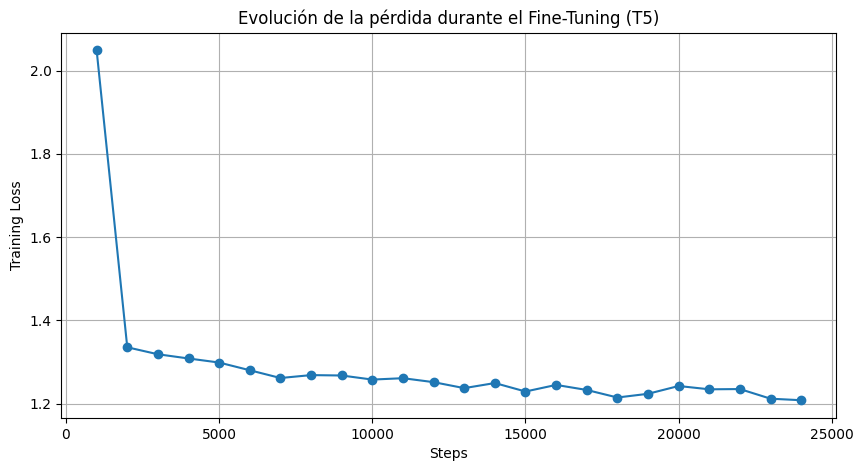

In [4]:
# --------------------------------------------------
# Grafica de perdida durante el entrenamiento (Fine-Tuning T5)
# --------------------------------------------------

import matplotlib.pyplot as plt

# Extraer historial del trainer
log_history = trainer.state.log_history

# Filtrar solo pasos con pérdida
steps = []
losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])

# Graficar
plt.figure(figsize=(10,5))
plt.plot(steps, losses, marker='o')

plt.title("Evolución de la pérdida durante el Fine-Tuning (T5)")
plt.xlabel("Steps")
plt.ylabel("Training Loss")
plt.grid(True)

plt.show()

In [5]:
# --------------------------------------------------
# Comparacion final: modelo base (Etapa 4) vs modelo fine-tuned (Etapa 5)
# --------------------------------------------------

import pandas as pd

# Metricas del modelo base de la Etapa 4
df_base = pd.DataFrame({
    "Modelo": ["t5-small_base", "t5-small_base", "t5-small_base"],
    "Split": ["test_eval_500", "test_eval_500", "test_eval_500"],
    "Metrica": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Valor": [0.084794, 0.023466, 0.078271]
})

# Metricas del modelo fine-tuned de la Etapa 5
df_ft = pd.DataFrame({
    "Modelo": ["T5_finetuned_parcial", "T5_finetuned_parcial", "T5_finetuned_parcial"],
    "Split": ["test_eval_500", "test_eval_500", "test_eval_500"],
    "Metrica": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Valor": [0.135884, 0.046933, 0.134613]
})

# Unir y pivotear para comparar
df_compare = pd.concat([df_base, df_ft], ignore_index=True)

tabla_comparativa = df_compare.pivot_table(
    index="Metrica",
    columns="Modelo",
    values="Valor"
).reset_index()

# Mejora absoluta y relativa
tabla_comparativa["Mejora_absoluta"] = (
    tabla_comparativa["T5_finetuned_parcial"] - tabla_comparativa["t5-small_base"]
)

tabla_comparativa["Mejora_relativa_%"] = (
    tabla_comparativa["Mejora_absoluta"] / tabla_comparativa["t5-small_base"] * 100
).round(2)

print("Comparacion final entre modelo base y modelo fine-tuned:\n")
print(tabla_comparativa)

print("\nConclusion:")
print("El modelo fine-tuned supera al modelo base en ROUGE-1, ROUGE-2 y ROUGE-L.")
print("Por lo tanto, el modelo seleccionado para despliegue sera: T5_finetuned_parcial")

# Guardado opcional de evidencia
tabla_comparativa.to_csv("/kaggle/working/comparacion_base_vs_finetuned.csv", index=False)

print("\nArchivo guardado:")
print("/kaggle/working/comparacion_base_vs_finetuned.csv")

Comparacion final entre modelo base y modelo fine-tuned:

Modelo  Metrica  T5_finetuned_parcial  t5-small_base  Mejora_absoluta  \
0       ROUGE-1              0.135884       0.084794         0.051090   
1       ROUGE-2              0.046933       0.023466         0.023467   
2       ROUGE-L              0.134613       0.078271         0.056342   

Modelo  Mejora_relativa_%  
0                   60.25  
1                  100.00  
2                   71.98  

Conclusion:
El modelo fine-tuned supera al modelo base en ROUGE-1, ROUGE-2 y ROUGE-L.
Por lo tanto, el modelo seleccionado para despliegue sera: T5_finetuned_parcial

Archivo guardado:
/kaggle/working/comparacion_base_vs_finetuned.csv


In [6]:
# Funcion de inferencia para resumir reviews


import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Cargar el modelo ya fine-tuned guardado
model_path = "/kaggle/working/t5_finetuned_final"

tokenizer_gradio = AutoTokenizer.from_pretrained(model_path)
model_gradio = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)

print("Modelo cargado para inferencia desde:")
print(model_path)

def resumir_review(texto):
    texto = str(texto).strip()
    
    if len(texto) == 0:
        return "Por favor, ingresa una review."
    
    entrada = "summarize: " + texto

    inputs = tokenizer_gradio(
        entrada,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        generated_ids = model_gradio.generate(
            **inputs,
            max_length=32,
            num_beams=4,
            early_stopping=True
        )

    resumen = tokenizer_gradio.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return resumen.strip()

# Prueba rapida
review_prueba = """
this product arrived on time, tastes excellent, and the packaging was very good.
i would definitely buy it again because the flavor is rich and fresh.
"""

print("\nReview de prueba:")
print(review_prueba)

print("\nResumen generado:")
print(resumir_review(review_prueba))

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Modelo cargado para inferencia desde:
/kaggle/working/t5_finetuned_final

Review de prueba:

this product arrived on time, tastes excellent, and the packaging was very good.
i would definitely buy it again because the flavor is rich and fresh.


Resumen generado:
great product


In [7]:

# CELDA FINAL 6a: guardar artefactos para el notebook 6b


import os
import json
import shutil

model_dir = "/kaggle/working/t5_finetuned_final"
deploy_dir = "/kaggle/working/t5_finetuned_deploy"

os.makedirs(deploy_dir, exist_ok=True)

# 1) Copiar carpeta del modelo fine-tuned
dest_model_dir = os.path.join(deploy_dir, "model")

if os.path.exists(dest_model_dir):
    shutil.rmtree(dest_model_dir)

shutil.copytree(model_dir, dest_model_dir)

# 2) Guardar configuracion de inferencia
inference_config = {
    "base_model": "t5-small",
    "task_prefix": "summarize: ",
    "max_input_length": 256,
    "max_output_length": 32,
    "num_beams": 4,
    "early_stopping": True
}

with open(os.path.join(deploy_dir, "inference_config.json"), "w") as f:
    json.dump(inference_config, f, indent=4)

# 3) Guardar ejemplos para demo opcional
demo_examples = [
    "this product arrived on time and the taste was amazing i would definitely buy it again because it was fresh and delicious",
    "the coffee has a strong flavor and good aroma but the package was damaged when it arrived",
    "these cookies are decent but a bit too sweet for my taste i probably would not order them again"
]

with open(os.path.join(deploy_dir, "demo_examples.json"), "w") as f:
    json.dump(demo_examples, f, indent=4)

print("Artefactos de despliegue guardados en:")
print(deploy_dir)
print("\nContenido:")
print(os.listdir(deploy_dir))
print("\nContenido del model/:")
print(os.listdir(dest_model_dir))

Artefactos de despliegue guardados en:
/kaggle/working/t5_finetuned_deploy

Contenido:
['model', 'inference_config.json', 'demo_examples.json']

Contenido del model/:
['tokenizer_config.json', 'generation_config.json', 'tokenizer.json', 'model.safetensors', 'config.json']
